
# **Decision Tree(Solución Titanic)**

UD2. Aprendizaxe Supervisada
MP.

Sistemas de Aprendizaxe Automáticos

IES de Teis (Vigo), Vanesa Resúa Eiras

Importación de paquetes

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


**1. Carga del fichero titanic_train.csv**

Cargamos los datos del fichero en un DataFrame y utilizamos el Id de los pasajeros como índice de las filas de la tabla.

In [15]:
dataset_df = pd.read_csv('titanic_train.csv', index_col='PassengerId')
#test_df = pd.read_csv('/content/sample_data/titanic_test.csv', index_col='PassengerId')
dataset_df


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


DATAFRAME TITANIC ---> Descripción de los campos

PassengerId: Identificador del pasajero dentro de la tabla

Survived: Indica si el pasajero sobrevivió -> 0 (No sobrevivió) y 1 (Si sobrevivió)

Pclass: clase de pasajero primera(1), segunda (2) o tercera (3)

Name: Nombre del pasajero

Sex: Sexo del pasajero -> Male o Female

Age: Edad (en años)

SibSp: Cantidad de hermanas/os o esposas/os a bordo

Parch: Cantidad de padres o hijos a bordo

Ticket: Número de ticket

Fare: Tarifa

Cabin: Cabina en la cual se encuentra alojado el pasajero

Embarked: Puerta de embarque C=Cherbourg Q=Queenstown S=Southampton


2. Representamos gráficamente la relación entre el sexo (cualitativa) y la supervivencia (cualitativa)

/tmp/ipykernel_24576/3682712855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=dataset_df, palette='Set2', ax=axes[0])


<Axes: xlabel='Survived', ylabel='count'>

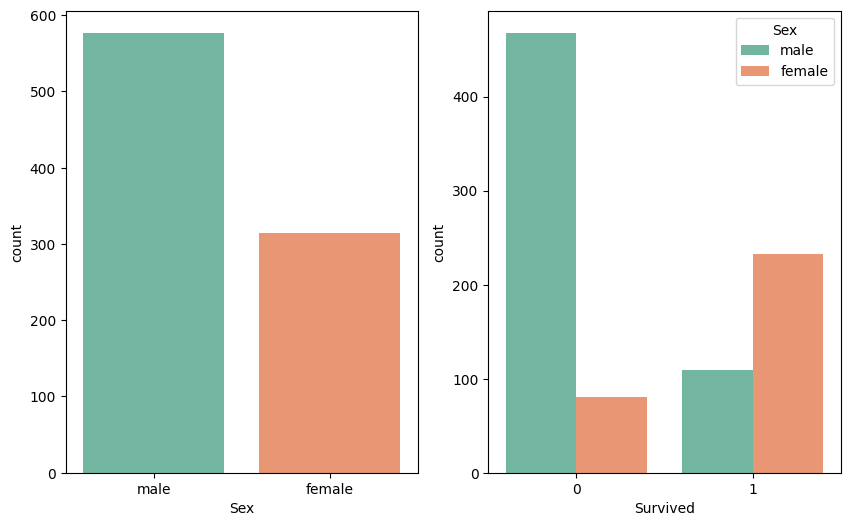

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10,6))
sns.countplot(x='Sex', data=dataset_df, palette='Set2', ax=axes[0])
sns.countplot(x='Survived',hue='Sex',data=dataset_df,palette='Set2', ax=axes[1])

Existe un patrón claro de que las mujeres tuvieron mayor supervivencia. En este caso, probablemente debido a la priorización de los botes salvavidas.

Representamos el patrón de supervivencia basado en la clase de los pasajeros (pclass).

/tmp/ipykernel_24576/2322494238.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=dataset_df, palette='Set2', ax=axes[0])


<Axes: xlabel='Pclass', ylabel='count'>

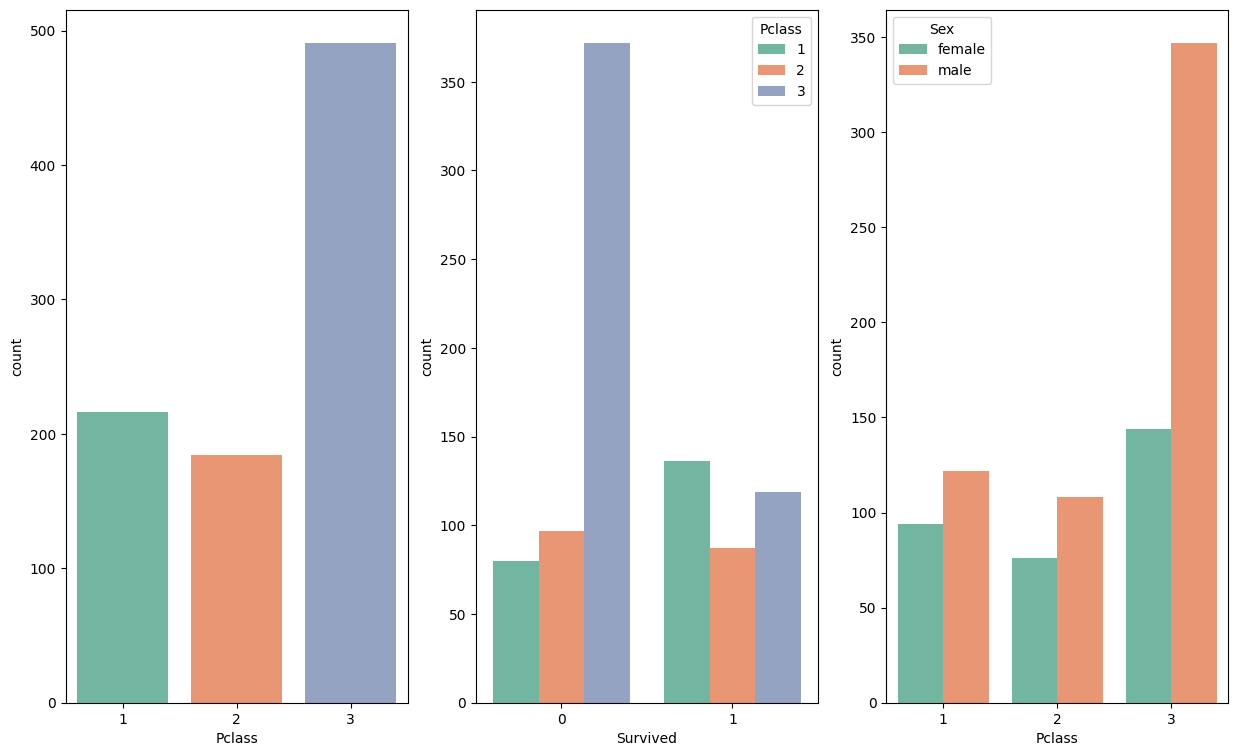

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15,9))
sns.countplot(x='Pclass', data=dataset_df, palette='Set2', ax=axes[0])
sns.countplot(x='Survived',hue='Pclass',data=dataset_df,palette='Set2', ax=axes[1])
sns.countplot(x='Pclass', hue='Sex', data=dataset_df, palette='Set2', ax=axes[2])

La mayoría de viajeros viajaban en tercera clase, y dentro de estos, la mayoría eran hombres, por lo que también (de acuerdo al patrón del sexo del pasajero) el número de no supervivientes es mayor. En este caso no se ve un patrón tan claro de la influencia de la clase con la supervivencia.

Empleamos un histograma para representar la edad de los pasajeron con un intervalo de 10 años.

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

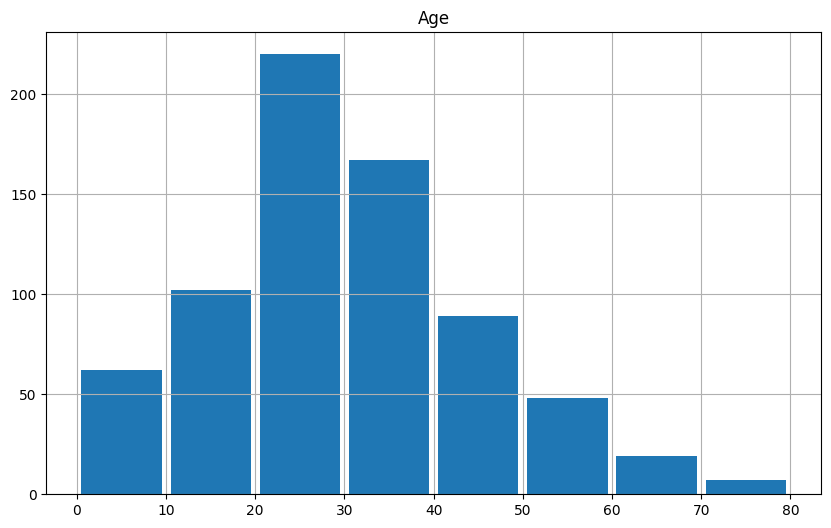

In [18]:
dataset_df.hist(column=['Age'], rwidth=0.9, bins=[*range(0,90,10)], figsize=(10, 6))

Para contrastar la clase (variable cualitativa) y la edad (variable cuantitativa) usamos el diagrama de cajas. Recordamos que la línea intermedia de la caja representa la mediana de los datos (el 50% de los datos están por debajo de este valor). Además de otra información, nos ofrece una visión clara de los valores atípicos (más allá de los extremos de la línea vertical).

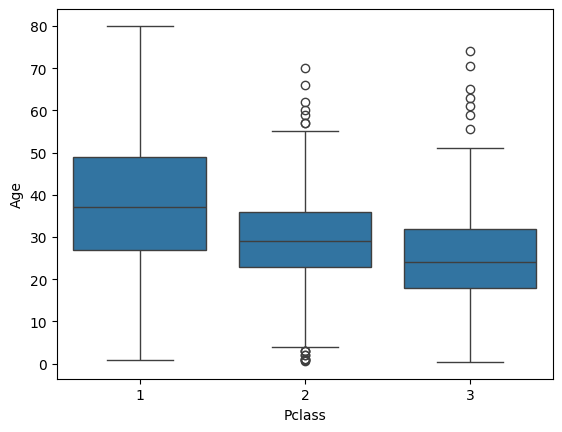

In [19]:
sns.boxplot(x='Pclass',y='Age',data=dataset_df)
plt.show()

La clase 1 es la que tiene menor sesgo puesto que la mediana se situa muy próxima a la mitad del rango de edad y además no presenta outliers (Valores atípicos). Sin embargo las clases 2 y 3 presentan valores atípicos que afectan a la robusted del clasificador.

3. Preprocessing

Assignamos el valor medio de la edad a los missing values de dicha variable.

In [20]:
#dataset_df
dataset_df['Age'].fillna(dataset_df['Age'].mean(), inplace=True)
dataset_df

/tmp/ipykernel_24576/118688065.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_df['Age'].fillna(dataset_df['Age'].mean(), inplace=True)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S


Comprobamos la cantidad de missing values que tenemos en los datos.

In [21]:
dataset_df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

En 687 de las 891 muestras, el valor del campo 'Cabin' es indeterminado, por lo tanto no lo podremos utilizar ya que tendríamos que suprimir la mayor parte de las muestra o asignarle un valor a partir de poca información. Por ello, podemos eliminarlo directamente.

In [22]:
# Lista de columnas a eliminar
drop_cols = ['Cabin']
dataset_df.drop(drop_cols, axis=1, inplace=True)

In [23]:

#cols_drop = ["Name", "Ticket", "Cabin"]
# Lista con los nombre de columnas de datos categóricos
cat_cols = ['Name', 'Sex', 'Ticket', 'Embarked']
dataset_df[cat_cols] = dataset_df[cat_cols].astype('category')
dataset_df[cat_cols] = dataset_df[cat_cols].apply(lambda x: x.cat.codes)

Puesto que el nombre y el ticket representan un valor único (o casi) para cada muestra no nos van a proporcionar ninguna información. Así que procedemos a eliminarlas:

In [24]:
drop_cols = ['Name', 'Ticket']
dataset_df.drop(drop_cols, axis=1, inplace=True)

La selección del resto de variable dependerá del conocimiento sobre en contexto. En este caso, el contexto es relativamente simple y podemos razonar las variables que pueden tener mayor influencia. En principio vamos a descartar la tarifa y la puerta de embarque:

In [25]:
drop_cols = ['Fare', 'Embarked']
dataset_df.drop(drop_cols, axis=1, inplace=True)

Una vez seleccionadas las variables procedemos a la división del dataset para el entrenamiento y el testeo.

In [26]:
# Separamos las variables independientes de la dependiente (la que quiero predecir)
X = dataset_df.loc[:, dataset_df.columns != 'Survived'].values
y = dataset_df.loc[:, 'Survived'].values
# Particionamos los datos para el entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

Creación del modelo

In [28]:
tree_clf = DecisionTreeClassifier(max_depth=2)

In [29]:
tree_clf.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
from sklearn.tree import export_graphviz

In [33]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,                     # modelo entrenado
    out_file='titanic.dot',       # nombre del archivo que va a crear
    feature_names=X_train.columns, # nombres de las columnas X
    class_names=['Fallece', 'Sobrevive'], # Qué significa 0 y 1
    rounded=True,
    filled=True
)



AttributeError: 'numpy.ndarray' object has no attribute 'columns'